# Robustness to Adversarial Attacks
How does test accuracy degrade under different threat models.
Classifier Training set covers all T3 attacks (incl.ALIE, IPM)

In [1]:
%load_ext autoreload
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
from fastnanoid import generate
from datetime import datetime

In [2]:
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))
lib_path = project_root / "lib"
sys.path.insert(0, str(lib_path))        
sys.path.insert(0, str(project_root))   

In [3]:
%autoreload 2
from lib.graph_factory import GraphFactory
from lib.proj_const_estimator import ProjConstEstimator
from lib.utils import fetch_dataset, get_alphas, rng, seed
from lib.classifier import ByzClassifier
from lib.system import SystemSimulator
from lib.config import BASE_CONF, LOGFILE, NUM_NODES

In [4]:
RUN_DIR = Path().resolve()
config = BASE_CONF
config['sys']['atk_type'] = 'ALIE'

In [5]:
global_dataset = fetch_dataset('MNIST')
gf = GraphFactory(config['train']['num_nodes'], config['train']['b'], seed('graph'))
proj_const_estimator = ProjConstEstimator(config, global_dataset, rng('proj-const-estimator')) 
classifier = ByzClassifier(config, global_dataset, rng('byz-classifier'))
sys_sim = SystemSimulator(config, global_dataset, rng('ml-system-sim'), LOGFILE)

In [6]:
proj_const_estimator.configure(gf,config)
proj_const = proj_const_estimator.estimate()

In [7]:
%%time
classifier.configure(gf,config, proj_const)
X_C_train, y_C_train, X_C_test, y_C_test = classifier.run_simulations()
classifier_metrics = classifier.train_and_eval(X_C_train, y_C_train, X_C_test, y_C_test)
C_opt_pt = classifier.clac_opt_operating_pt(0.8)
C_best_est, C_pre_pipe = classifier.get_params()

CPU times: user 17min 4s, sys: 21.6 s, total: 17min 26s
Wall time: 1min 27s


In [8]:
sim_params = {
    'algorithms':['RDSGD', 'IOS', 'SCC', 'TriMean', 'CooMed'],
    'atk_type':config['sys']['atk_type'],
}

In [9]:
%%time
sim_params['threat_model']='T0'

run_results = dict()
RUN_ID = generate()
run_results['timestamp'] = pd.to_datetime(datetime.now())
run_results['proj_const'] = proj_const
run_results.update(C_opt_pt)

sys_sim.configure(gf, config, proj_const, C_pre_pipe, C_best_est, C_opt_pt)
df_t0 = sys_sim.simulate(sim_params, run_results)
payload_t0 = sys_sim.log_results(run_results, RUN_DIR, RUN_ID)

==========RDSGD==========
[k=35] train_loss=1.7429
[k=70] train_loss=1.7442
[k=105] train_loss=1.7514
===========IOS===========
[k=35] train_loss=1.5609
[k=70] train_loss=1.5562
[k=105] train_loss=1.5571
===========SCC===========
[k=35] train_loss=1.5595
[k=70] train_loss=1.5561
[k=105] train_loss=1.5555
=========TriMean=========
[k=35] train_loss=1.5871
[k=70] train_loss=1.5800
[k=105] train_loss=1.5784
==========CooMed=========
[k=35] train_loss=1.5929
[k=70] train_loss=1.5859
[k=105] train_loss=1.5841
CPU times: user 34min 23s, sys: 10.3 s, total: 34min 33s
Wall time: 1min 41s


In [10]:
%%time
sim_params['threat_model']='T3'

run_results = dict()
RUN_ID = generate()
run_results['timestamp'] = pd.to_datetime(datetime.now())
run_results['proj_const'] = proj_const
run_results.update(C_opt_pt)

sys_sim.configure(gf, config, proj_const, C_pre_pipe, C_best_est, C_opt_pt)
df_t3 = sys_sim.simulate(sim_params, run_results)
payload_t3 = sys_sim.log_results(run_results, RUN_DIR, RUN_ID)

==========RDSGD==========
[k=35] train_loss=1.6001
[k=70] train_loss=1.5785
[k=105] train_loss=1.5758
===========IOS===========
[k=35] train_loss=1.6016
[k=70] train_loss=1.5945
[k=105] train_loss=1.5931
===========SCC===========
[k=35] train_loss=1.5798
[k=70] train_loss=1.5722
[k=105] train_loss=1.5708
=========TriMean=========
[k=35] train_loss=1.6363
[k=70] train_loss=1.6249
[k=105] train_loss=1.6220
==========CooMed=========
[k=35] train_loss=1.6431
[k=70] train_loss=1.6324
[k=105] train_loss=1.6296
CPU times: user 29min 6s, sys: 5.86 s, total: 29min 12s
Wall time: 1min 25s


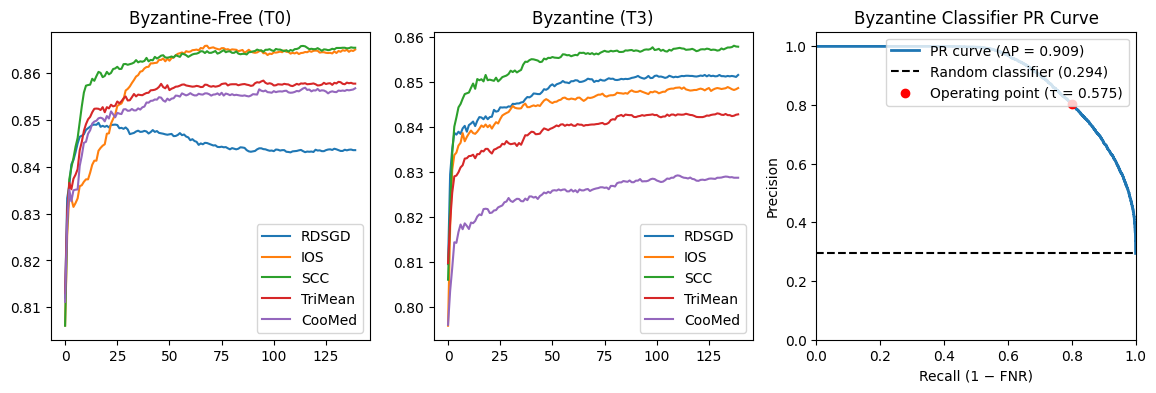

In [13]:
fig, ax = plt.subplots(1,3, figsize=(14,4))
iter_idx = np.arange(config['sys']['K'])

for alg in sim_params['algorithms']:
    ax[0].plot(iter_idx, df_t0.loc[alg]['test_acc'], label=alg)
    ax[1].plot(iter_idx, df_t3.loc[alg]['test_acc'], label=alg)

classifier.plot_pr(ax[2])
ax[0].legend(loc='lower right')
ax[1].legend(loc='lower right')
ax[0].set_title('Byzantine-Free (T0)')
ax[1].set_title('Byzantine (T3)')
plt.show()

In [14]:
images_dir = project_root / RUN_DIR / "images"
images_dir.mkdir(parents=True, exist_ok=True)
full_path = images_dir / "results.png"
fig.savefig(full_path, bbox_inches='tight', dpi=300)

In [15]:
BASE_CONF

{'alpha_init': 0.5,
 'alpha_decay': 0.1,
 'graph_type': 'erdos-renyi',
 'graph_weights': 'MH_gen',
 'graph_args': {'er_p': np.float64(0.4493598410330987),
  'tar_pi_dir_alpha': 10,
  'MH_target_pi': array([0.02938069, 0.03599152, 0.047131  , 0.03001002, 0.05411977,
         0.09469823, 0.03743104, 0.04139602, 0.06160983, 0.05779978,
         0.07187934, 0.06371764, 0.04587622, 0.03028448, 0.08033992,
         0.06140026, 0.03487551, 0.0295095 , 0.06093801, 0.03161123])},
 'reg_param': 0.2,
 'batch_sz': 100,
 'data_heterogeneity': 1,
 'sys': {'num_nodes': 20, 'b': 5, 'K': 140, 'atk_type': 'ALIE'},
 'train': {'gamma_C': 0.25,
  'beta_C': 0.5,
  'train_atks': ['label_flip', 'sign_flip', 'gaussian', 'ALIE', 'IPM'],
  'val_atks': ['label_flip', 'sign_flip', 'gaussian', 'ALIE', 'IPM'],
  'num_nodes': 20,
  'b': 5,
  'K': 140}}